# 第一回: 入試問題を解く (その1) 記述する

```{hint}
* 次の例題の出典は？
```

### 2.12.1 操作環境の準備

In [ ]:
using Pkg
Pkg.activate("../..")
Pkg.instantiate()
using GeoGebra
ENV["GGB_DIRECT_TRANSPORT"] = true

In [ ]:
inject_applet()

In [ ]:
versioninfo()

In [ ]:
@ggb :api getVersion()

### 2.12.2 作図    

In [ ]:
@ggb :const :new

In [ ]:
@ggb A = (0, -8, 0)
@ggb B = (6, 0, 0)
@ggb C = (-6, 0, 0)

In [ ]:
@ggb Polygon(:A, :B, :C)

In [ ]:
@ggb I = TriangleCenter(:A, :B, :C, 1)
@ggb G = TriangleCenter(:A, :B, :C, 2)

In [ ]:
@ggb PerpendicularLine(:G, :xOyPlane)

In [ ]:
@ggb P = Point(:f)

In [ ]:
@ggb Segment(:P, :A)
@ggb Segment(:P, :B)
@ggb Segment(:P, :C)

In [ ]:
@ggb Line(:A, :I)

In [ ]:
@ggb D = Intersect(:j, :a)

In [ ]:
@ggb Circle(:P, :D, :I)

In [ ]:
@ggb {Intersect(:d, :g)}

In [ ]:
@ggb E = l1(1)

In [ ]:
@ggb Angle(:P, :E, :D)

In [ ]:
@ggb Angle(:P, :I, :D)

In [ ]:
@ggb Segment(:E, :D)
@ggb Segment(:P, :I)

In [ ]:
@ggb "xyPlane = xOyPlane"
@ggb yzPlane = Plane(:yAxis, :zAxis)

### 2.12.3 作図手順

In [ ]:
@ggb :const

```{seealso}
* [令和８年度試験 | 独立行政法人 大学入試センター](https://www.dnc.ac.jp/kyotsu/shiken_jouhou/r8/)
* [【日経】共通テスト2026　問題と正解（旧センター試験） - 日本経済新聞](https://www.nikkei.com/telling/DGXZTS00018940U5A221C2000000/)
```

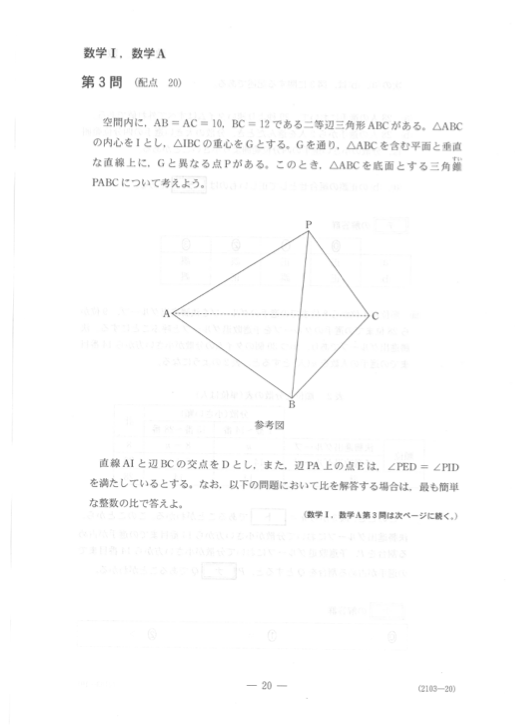

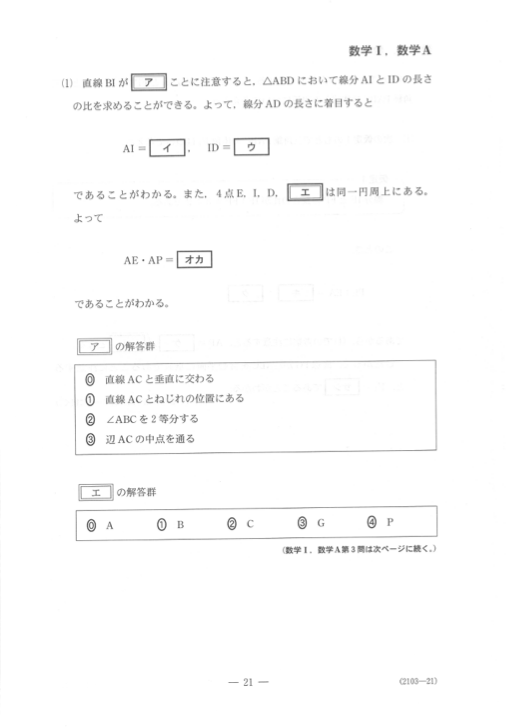

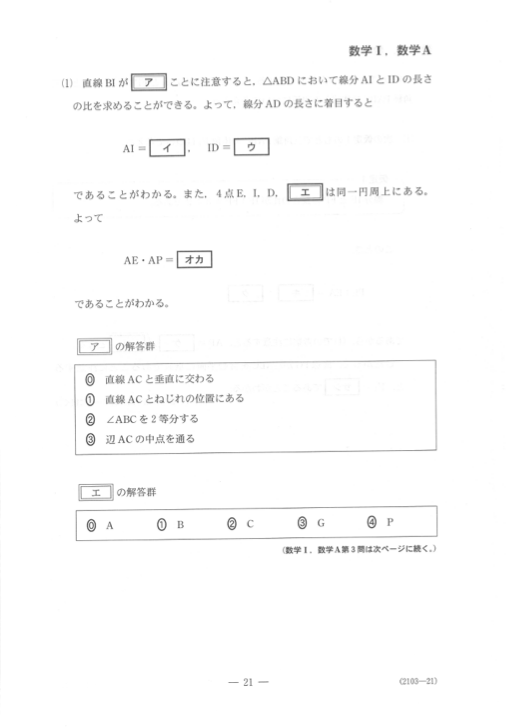

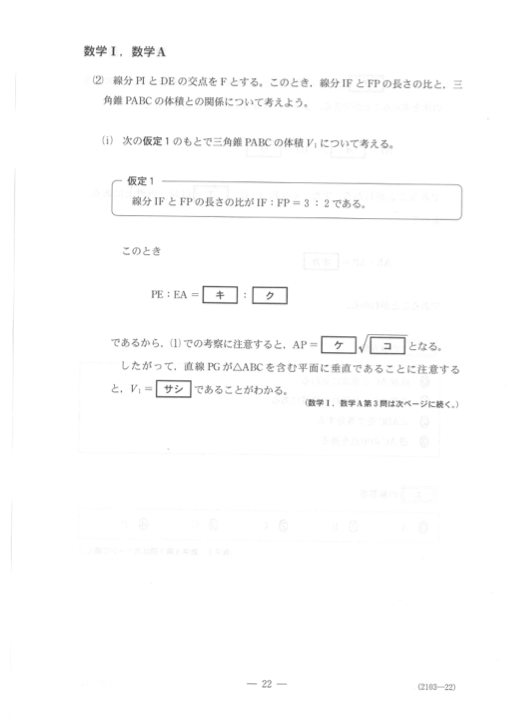

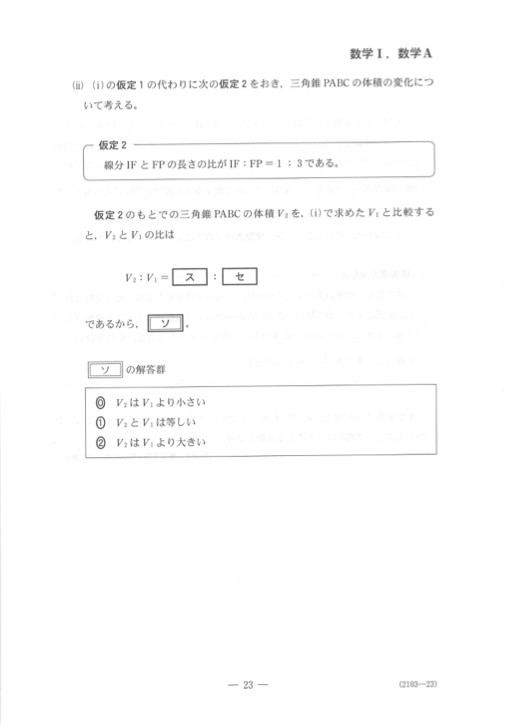

```{warning}
辺PA上の点Eは、$∠PED = ∠PID$を満たしているとする
```

### 2.12.4 関係の記述

In [ ]:
using PythonCall

In [ ]:
ggb = pyimport("ggblab")
ggb.file = pyimport("ggblab.file").ggb_file()
ggb.parser = pyimport("ggblab.parser").ggb_parser()
ggb.schema = pyimport("ggblab.schema").ggb_schema()

In [ ]:
ggbex = pyimport("ggblab_extra")
ConstructionIO = ggbex.ConstructionIO
ConstructionTreeParser = ggbex.ConstructionTreeParser

In [ ]:
pl = pyimport("polars")
ggbex_sympy = pyimport("ggblab_extra.sympy")

In [ ]:
ggbex_sympy.set_applet_3d(true)

In [ ]:
ggbex_sympy.get_applet_3d()

In [ ]:
df = @await ConstructionIO.initialize_dataframe(ggb, use_applet=true)

### 2.12.5 関係の記述: 同一平面上のオブジェクトを抽出

In [ ]:
df2 = ggbex_sympy.attach_object3d(df)["Name", "Type", "Command", "Value", "object3d"]

In [ ]:
df3 = ggbex_sympy.enumerate_plane_members(df2)
    # df2.filter(pl.col("Type").is_in(["point", "plane"]))

In [ ]:
pylist(df3[-1]["plane_members"])

In [ ]:
pylist(df3[-2]["plane_members"])

In [ ]:
o1 = [o.obj for o in df2.filter(pl.col("Type").is_in(["point"]))["object3d"]]

In [ ]:
o0 = [o.obj for o in df2.filter(pl.col("Type").is_in(["plane"]))["object3d"]]

In [ ]:
for p in o1
    println(p, ggbex_sympy.point_on_plane(p, o0[2]))
end

In [ ]:
string(ggbex_sympy.plane_from_value("xyPlane: z = 0"))

In [ ]:
ggbex_sympy.plane_from_value("yzPlane: x = 0")

In [ ]:
ggbex_sympy.Object3D.from_value_command(type_="plane", value="xyPlane: z = 0", command="xOyPlane")

In [ ]:
ggbex_sympy.object3d._try_surface_from_value("xyPlane: z = 0")

In [ ]:
for r in df.filter(pl.col("Type").is_in(["plane"]))["Name","Type","Command","Value"].iter_rows()
    println(ggbex_sympy.plane_from_value(r[3]))
end